# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально 

**Среда:** Python, scikit-learn, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## Результаты обучения
После выполнения работы вы должны уметь:
- различать парадигмы обучения (supervised / unsupervised / reinforcement learning);
- выбирать модель под тип данных и задачу;
- строить baseline для классификации или регрессии;
- выбирать и интерпретировать метрики качества (accuracy, precision, recall, F1, MSE, RMSE, R²);
- сравнивать несколько моделей и делать обоснованный вывод о лучшем baseline.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 77


## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


_Ваш ответ:_ Выбранный датасет - diabetes - относится к парадигме supervised, поскольку обучение идет с учителем. Тип задачи - регрессия. Целевая переменная - абстрактная величина - прогрессирование диабета

## 2. Загрузка и разведочный анализ данных (EDA)

In [2]:
# загрузка датасета
data = load_diabetes(as_frame=True)
df = data.frame

df.head() if df is not None else None


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# разведочный анализ данных
display(df.shape)
display(df.dtypes)
display(df.isna().sum())
df.describe()


(442, 11)

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

_Ваш ответ:_ Пропусков в данных нет, среднее отклонение достаточно велико у целевой переменной. Признаки уже масштабированы. Предобработка необязательна

## 3. Предобработка данных

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

display(X_train_scaled.shape)
X_test_scaled.shape



(353, 10)

(89, 10)

## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [5]:
# Модель линейная регрессия
model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -1. ,-10.08, 25.04,..., 11.84, 34.76, 2.56]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,150.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[37.69,22.84,20.66,...,12.53, 5.21, 1.7 ]"


In [6]:
# Модель KNN
model_2 = KNeighborsRegressor(
    n_neighbors=10,
    weights='distance',
    n_jobs=-1,
)
model_2.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [7]:
# Модель MPL
model_3 = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)
model_3.fit(X_train_scaled, y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",72
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",20
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to de

## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [8]:
results = pd.DataFrame(columns=["model", "MSE", "RMSE", "R2"])
y_pred_lin = model_1.predict(X_test_scaled)
mse_lin  = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin   = r2_score(y_test, y_pred_lin)
results.loc[len(results)] = ["LinearRegression", mse_lin, rmse_lin, r2_lin]

y_pred_knn = model_2.predict(X_test_scaled)
mse_knn  = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn   = r2_score(y_test, y_pred_knn)
results.loc[len(results)] = ["KNeighborsRegressor", mse_knn, rmse_knn, r2_knn]

y_pred_mlp = model_3.predict(X_test_scaled)
mse_mlp  = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp   = r2_score(y_test, y_pred_mlp)
results.loc[len(results)] = ["MLPRegressor", mse_mlp, rmse_mlp, r2_mlp]
results

,model,MSE,RMSE,R2
0,LinearRegression,2258.830576,47.527156,0.657920
1,KNeighborsRegressor,3001.343930,54.784523,0.545473
2,MLPRegressor,2325.439937,48.222816,0.647832


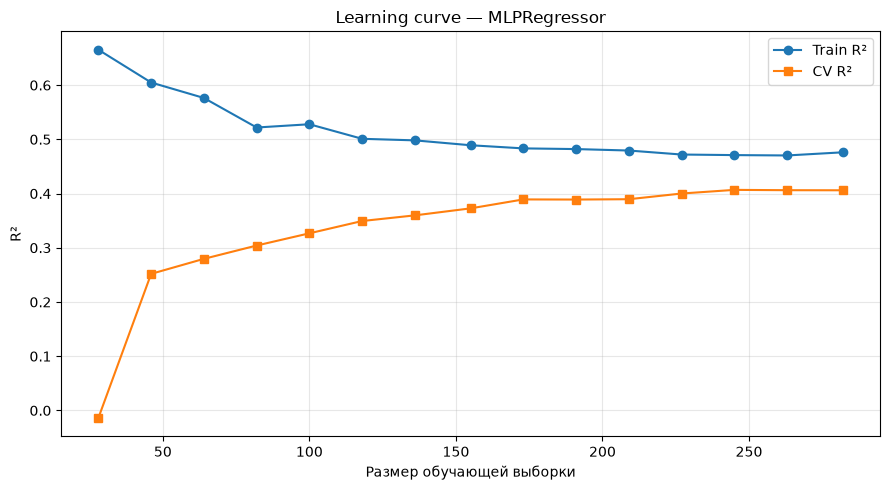

In [9]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model_1, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 15),
    cv=5, scoring='r2', n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Train R²')
plt.plot(train_sizes, val_mean,   's-', label='CV R²')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('R²')
plt.title('Learning curve — MLPRegressor')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

_Ваш ответ:_ 

## 6. Анализ ошибок

In [10]:
y_pred = model_1.predict(X_test_scaled)
errors = y_test.values - y_pred
abs_err = np.abs(errors)

print(f'Bias (средняя ошибка): {errors.mean():+.2f}')
print(f'MAE:  {abs_err.mean():.2f}')
print(f'RMSE: {np.sqrt((errors**2).mean()):.2f}')

Bias (средняя ошибка): +7.64
MAE:  39.20
RMSE: 47.53


## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

_Ваш ответ:_ Лучший результат показала MLP. Линейная регрессия не показала сильный результат из-за слабой зависимости параметров и целевой переменной

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже 

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.


In [11]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

models = {
    'LinearRegression': make_pipeline(StandardScaler(), LinearRegression()),
    'KNN':              make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),
    'MLP':              make_pipeline(StandardScaler(),
                                      MLPRegressor(hidden_layer_sizes=(32,),
                                                   max_iter=2000, early_stopping=True,
                                                   random_state=RANDOM_STATE)),
}

cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'R2':   'r2',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE':  'neg_mean_absolute_error',
}

cv_results = {}
for metric_name, scorer in scoring.items():
    fold_scores = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv,
                                 scoring=scorer, n_jobs=-1)
        if scorer.startswith('neg'):
            scores = -scores
        fold_scores[name] = scores
    cv_results[metric_name] = pd.DataFrame(fold_scores)

summary = pd.concat(
    {m: cv_results[m].agg(['mean', 'std', 'min', 'max']) for m in scoring},
    axis=0
).round(3)
display(summary)


LinearRegression     KNN     MLP
R2   mean             0.465   0.365   0.430
     std              0.133   0.128   0.144
     min              0.211   0.215   0.274
     max              0.668   0.632   0.672
RMSE mean            54.628  59.698  56.365
     std              6.239   6.286   7.300
     min             45.107  51.619  44.994
     max             60.987  67.617  67.345
MAE  mean            44.512  46.988  44.899
     std              5.382   5.634   6.198
     min             36.408  39.691  35.680
     max             52.323  54.414  54.606

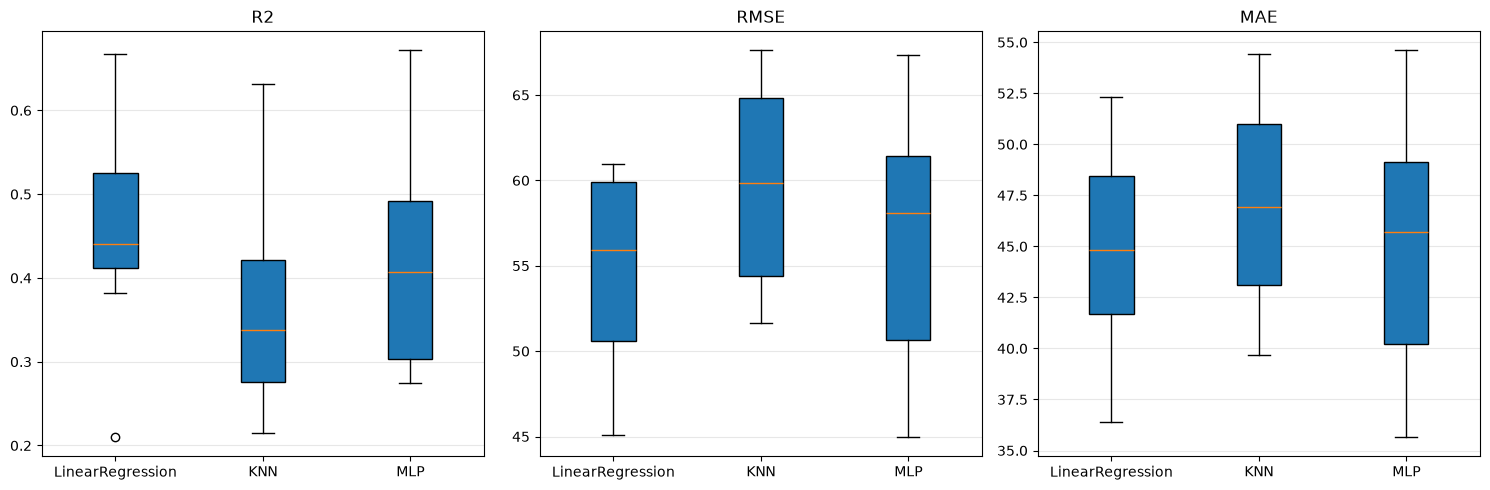

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, scoring.keys()):
    df_m = cv_results[metric]
    ax.boxplot([df_m[c] for c in df_m.columns],
               tick_labels=df_m.columns, patch_artist=True)
    ax.set_title(metric)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---



## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Минимум 3 модели, минимум 2 метрики, минимум 1 визуализация.
